# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Datasets

transaction = pd.read_excel("QVI_transaction_data.xlsx")
purchase = pd.read_csv("QVI_purchase_behaviour.csv")

# Data Inspection

In [3]:
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
print("Transactions: ", transaction.shape, "Purchase", purchase.shape)  


Transactions:  (264836, 8) Purchase (72637, 3)


In [6]:
print("Transactions columns: ", transaction.columns, "Purchase columns: ", purchase.columns)  

Transactions columns:  Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object') Purchase columns:  Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='object')


In [7]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [8]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [9]:
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [10]:
purchase.describe(include="all")

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
count,7.263700e+04,72637,72637
unique,NaN,7,3
top,NaN,RETIREES,Mainstream
freq,NaN,14805,29245
mean,1.361859e+05,NaN,NaN
std,8.989293e+04,NaN,NaN
min,1.000000e+03,NaN,NaN
25%,6.620200e+04,NaN,NaN
50%,1.340400e+05,NaN,NaN
75%,2.033750e+05,NaN,NaN


# Data Cleaning

In [11]:
transaction.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [12]:
purchase.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [13]:
transaction.duplicated().sum()

np.int64(1)

In [14]:
purchase.duplicated().sum()

np.int64(0)

In [15]:
transaction = transaction.drop_duplicates()

In [16]:
transaction.duplicated().sum()

np.int64(0)

In [17]:

#Conversation of data into readable date format

transaction["DATE"] = pd.to_datetime(
    transaction["DATE"],
    origin="1899-12-30",
    unit="D"
)

In [18]:
transaction["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [19]:
transaction[transaction["PROD_QTY"] == transaction["PROD_QTY"].max()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [20]:
# This customer has very suspicious transaction so we are here reading his whole history of transaction

transaction[transaction["LYLTY_CARD_NBR"] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [21]:
# LYLTY_CARD_NBR = 226000 is highly suspious form our analysis so we have to remove it because it can cause major change in our further analysis
transaction = transaction[transaction["LYLTY_CARD_NBR"] != 226000]

In [22]:
transaction["PROD_QTY"].max()   #After removing LYLTY_CARD_NBR = 226000    max is just 5

np.int64(5)

# Feature Engineering

In [23]:
# we know product name with it's weight in grams so now we are creating new column which only contain vaules of that grams
transaction["PACK_SIZE"] = (
    transaction["PROD_NAME"]
    .str.extract(r'(\d+)')
    .astype(int)
)

In [24]:
transaction[["PROD_NAME", "PACK_SIZE"]].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
5,Old El Paso Salsa Dip Tomato Mild 300g,300
6,Smiths Crinkle Chips Salt & Vinegar 330g,330
7,Grain Waves Sweet Chilli 210g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,150
9,Grain Waves Sour Cream&Chives 210G,210


In [25]:
transaction["PACK_SIZE"].describe()

count    264833.000000
mean        182.425540
std          64.325268
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

In [26]:
transaction["PACK_SIZE"].unique()

array([175, 170, 150, 300, 330, 210, 270, 220, 125, 110, 134, 380, 180,
       165, 135, 250, 200, 160, 190,  90,  70])

In [27]:
transaction[["PROD_NAME", "PACK_SIZE"]].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
5,Old El Paso Salsa Dip Tomato Mild 300g,300
6,Smiths Crinkle Chips Salt & Vinegar 330g,330
7,Grain Waves Sweet Chilli 210g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,150
9,Grain Waves Sour Cream&Chives 210G,210


In [28]:
transaction["PROD_NAME"].str.split().str[0].value_counts()

PROD_NAME
Kettle        41288
Smiths        28859
Pringles      25102
Doritos       24962
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Old            9324
Tyrrells       6442
Grain          6272
Natural        6050
Red            5885
Cheezels       4603
CCs            4551
Woolworths     4437
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

# Data Standarization

In [29]:
transaction["BRAND"] = transaction["PROD_NAME"].str.split().str[0]

In [30]:
# Here we seperate brand name and corrected the incorrects or repeated onces

transaction["BRAND"] = transaction["PROD_NAME"].str.split().str[0]

transaction["BRAND"] = transaction["BRAND"].replace({
    "Dorito": "Doritos",
    "Smith": "Smiths",
    "Infzns": "Infuzions",
    "Grain": "Grain Waves",
    "GrnWves": "Grain Waves",
    "WW": "Woolworths",
    "NCC": "Natural Chip Co.",
    "Natural": "Natural Chip Co.",
    "RRD": "Red Rock Deli",
    "Red": "Red Rock Deli",
    "Old": "Old El Paso",
    "Snbts": "Sunbites",
    "French": "French Fries",
    "Burger": "Burger Rings"
})

In [31]:
transaction["BRAND"].value_counts()

BRAND
Kettle              41288
Smiths              31822
Doritos             28145
Pringles            25102
Red Rock Deli       17779
Woolworths          14757
Infuzions           14201
Thins               14075
Cobs                 9693
Tostitos             9471
Twisties             9454
Old El Paso          9324
Grain Waves          7740
Natural Chip Co.     7469
Tyrrells             6442
Cheezels             4603
CCs                  4551
Sunbites             3008
Cheetos              2927
Burger Rings         1564
French Fries         1418
Name: count, dtype: int64

In [32]:
# Now we are merging purchase behaviour and transaction file, but instead of overwriting on one file we are here creating new file name as merged_data

merged_data = pd.merge(
    transaction,
    purchase,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [33]:
merged_data.shape

(264833, 12)

In [ ]:
# Here we are saving merged data into csv file QVI_Merged_Cleaned_Data

merged_data.to_csv(
    "QVI_Merged_Cleaned_Data.csv",
    index=False
)

In [ ]:
merged_data.head()

# Let's Start EDA (Exploratory Data Analysis)

In [35]:
# Total Sales
total_sales = merged_data["TOT_SALES"].sum()

print(f"Total Sales: {total_sales:,.2f}")

Total Sales: 1,933,109.00


In [36]:
# Total Transactions
total_transactions = merged_data["TXN_ID"].nunique()

print(f"Total Transactions: {total_transactions:,}")

Total Transactions: 263,125


In [37]:
# Total Customers
total_customers = merged_data["LYLTY_CARD_NBR"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 72,636


In [38]:
# Average Sales per Transaction
avg_sales_per_transaction = total_sales / total_transactions

print(f"Average Sales per Transaction: {avg_sales_per_transaction:.2f}")

Average Sales per Transaction: 7.35


In [39]:
# Average Transactions per Customer
avg_transactions_per_customer = total_transactions / total_customers

print(f"Average Transactions per Customer: {avg_transactions_per_customer:.2f}")

Average Transactions per Customer: 3.62


In [40]:
merged_data.shape[0]

264833

In [41]:
# Sales by lifestage like which lifestage as achive more sales

sales_by_lifestage = (
    merged_data
    .groupby("LIFESTAGE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_lifestage

LIFESTAGE
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
OLDER FAMILIES            352467.20
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
Name: TOT_SALES, dtype: float64

In [42]:
# Sales by premium customer

sales_by_premium = (
    merged_data
    .groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_premium

PREMIUM_CUSTOMER
Mainstream    750744.50
Budget        676211.55
Premium       506152.95
Name: TOT_SALES, dtype: float64

In [43]:
# Group of Premium custoemr and Lifestage of that customer
sales_segment = (
    merged_data
    .groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

sales_segment

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              168363.25
YOUNG SINGLES/COUPLES   Mainstream          157621.60
RETIREES                Mainstream          155677.05
YOUNG FAMILIES          Budget              139345.85
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132257.15
RETIREES                Budget              113147.80
OLDER FAMILIES          Mainstream          103445.55
RETIREES                Premium              97646.05
YOUNG FAMILIES          Mainstream           92788.75
MIDAGE SINGLES/COUPLES  Mainstream           90803.85
YOUNG FAMILIES          Premium              84025.50
OLDER FAMILIES          Premium              80658.40
YOUNG SINGLES/COUPLES   Budget               61141.60
MIDAGE SINGLES/COUPLES  Premium              58432.65
YOUNG SINGLES/COUPLES   Premium              41642.10
MIDAGE SINGLES/COUPLES  Budget           

In [44]:
# Customer count in each segment

customer_count = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .sort_values(ascending=False)
)

customer_count

LIFESTAGE               PREMIUM_CUSTOMER
YOUNG SINGLES/COUPLES   Mainstream          8088
RETIREES                Mainstream          6479
OLDER SINGLES/COUPLES   Mainstream          4930
                        Budget              4929
                        Premium             4750
OLDER FAMILIES          Budget              4675
RETIREES                Budget              4454
YOUNG FAMILIES          Budget              4017
RETIREES                Premium             3872
YOUNG SINGLES/COUPLES   Budget              3779
MIDAGE SINGLES/COUPLES  Mainstream          3340
OLDER FAMILIES          Mainstream          2831
YOUNG FAMILIES          Mainstream          2728
YOUNG SINGLES/COUPLES   Premium             2574
YOUNG FAMILIES          Premium             2433
MIDAGE SINGLES/COUPLES  Premium             2431
OLDER FAMILIES          Premium             2273
MIDAGE SINGLES/COUPLES  Budget              1504
NEW FAMILIES            Budget              1112
                        Main

In [45]:
avg_sales_per_customer = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(
        Total_Sales=("TOT_SALES", "sum"),
        Customers=("LYLTY_CARD_NBR", "nunique")
    )
)

avg_sales_per_customer["Avg_Sales_Per_Customer"] = (
    avg_sales_per_customer["Total_Sales"] /
    avg_sales_per_customer["Customers"]
)

avg_sales_per_customer = avg_sales_per_customer.sort_values(
    by="Avg_Sales_Per_Customer",
    ascending=False
)

avg_sales_per_customer

Total_Sales  Customers  \
LIFESTAGE              PREMIUM_CUSTOMER                           
OLDER FAMILIES         Mainstream          103445.55       2831   
                       Budget              168363.25       4675   
                       Premium              80658.40       2273   
YOUNG FAMILIES         Budget              139345.85       4017   
                       Premium              84025.50       2433   
                       Mainstream           92788.75       2728   
OLDER SINGLES/COUPLES  Premium             132257.15       4750   
                       Budget              136769.80       4929   
MIDAGE SINGLES/COUPLES Mainstream           90803.85       3340   
OLDER SINGLES/COUPLES  Mainstream          133393.80       4930   
RETIREES               Budget              113147.80       4454   
                       Premium              97646.05       3872   
MIDAGE SINGLES/COUPLES Premium              58432.65       2431   
RETIREES               Mainstream          155677.05       6479   
MIDAGE SINGLES/COUPLES Budget               35514.80       1504   
NEW FAMILIES           Mainstream           17013.90        849   
                       Budget               21928.45       1112   
                       Premium              11491.10        588   
YOUNG SINGLES/COUPLES  Mainstream          157621.60       8088   
                       Budget               61141.60       3779   
                       Premium              41642.10       2574   

                                         Avg_Sales_Per_Customer  
LIFESTAGE              PREMIUM_CUSTOMER                          
OLDER FAMILIES         Mainstream                     36.540286  
                       Budget                         36.013529  
                       Premium                        35.485438  
YOUNG FAMILIES         Budget                         34.689034  
                       Premium                        34.535758  
                       Mainstream                     34.013471  
OLDER SINGLES/COUPLES  Premium                        27.843611  
                       Budget                         27.747981  
MIDAGE SINGLES/COUPLES Mainstream                     27.186781  
OLDER SINGLES/COUPLES  Mainstream                     27.057566  
RETIREES               Budget                         25.403637  
                       Premium                        25.218505  
MIDAGE SINGLES/COUPLES Premium                        24.036466  
RETIREES               Mainstream                     24.027944  
MIDAGE SINGLES/COUPLES Budget                         23.613564  
NEW FAMILIES           Mainstream                     20.039929  
                       Budget                         19.719829  
                       Premium                        19.542687  
YOUNG SINGLES/COUPLES  Mainstream                     19.488328  
                       Budget                         16.179307  
                       Premium                        16.177972

In [46]:
avg_units_per_customer = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(
        Total_Units=("PROD_QTY", "sum"),
        Customers=("LYLTY_CARD_NBR", "nunique")
    )
)

avg_units_per_customer["Avg_Units_Per_Customer"] = (
    avg_units_per_customer["Total_Units"] /
    avg_units_per_customer["Customers"]
)

avg_units_per_customer = avg_units_per_customer.sort_values(
    by="Avg_Units_Per_Customer",
    ascending=False
)

avg_units_per_customer

Total_Units  Customers  \
LIFESTAGE              PREMIUM_CUSTOMER                           
OLDER FAMILIES         Mainstream              27756       2831   
                       Budget                  45065       4675   
                       Premium                 21771       2273   
YOUNG FAMILIES         Budget                  37111       4017   
                       Premium                 22406       2433   
                       Mainstream              25044       2728   
OLDER SINGLES/COUPLES  Premium                 33984       4750   
                       Budget                  35220       4929   
                       Mainstream              34997       4930   
MIDAGE SINGLES/COUPLES Mainstream              22699       3340   
RETIREES               Budget                  28764       4454   
                       Premium                 24884       3872   
MIDAGE SINGLES/COUPLES Premium                 15526       2431   
                       Budget                   9496       1504   
RETIREES               Mainstream              40518       6479   
NEW FAMILIES           Mainstream               4319        849   
                       Premium                  2957        588   
                       Budget                   5571       1112   
YOUNG SINGLES/COUPLES  Mainstream              38632       8088   
                       Budget                  16671       3779   
                       Premium                 11331       2574   

                                         Avg_Units_Per_Customer  
LIFESTAGE              PREMIUM_CUSTOMER                          
OLDER FAMILIES         Mainstream                      9.804309  
                       Budget                          9.639572  
                       Premium                         9.578091  
YOUNG FAMILIES         Budget                          9.238486  
                       Premium                         9.209207  
                       Mainstream                      9.180352  
OLDER SINGLES/COUPLES  Premium                         7.154526  
                       Budget                          7.145466  
                       Mainstream                      7.098783  
MIDAGE SINGLES/COUPLES Mainstream                      6.796108  
RETIREES               Budget                          6.458015  
                       Premium                         6.426653  
MIDAGE SINGLES/COUPLES Premium                         6.386672  
                       Budget                          6.313830  
RETIREES               Mainstream                      6.253743  
NEW FAMILIES           Mainstream                      5.087161  
                       Premium                         5.028912  
                       Budget                          5.009892  
YOUNG SINGLES/COUPLES  Mainstream                      4.776459  
                       Budget                          4.411485  
                       Premium                         4.402098

In [47]:
avg_price_per_unit = (
    merged_data
    .groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(
        Total_Sales=("TOT_SALES", "sum"),
        Total_Units=("PROD_QTY", "sum")
    )
)

avg_price_per_unit["Avg_Price_Per_Unit"] = (
    avg_price_per_unit["Total_Sales"] /
    avg_price_per_unit["Total_Units"]
)

avg_price_per_unit = avg_price_per_unit.sort_values(
    by="Avg_Price_Per_Unit",
    ascending=False
)

avg_price_per_unit

Total_Sales  Total_Units  \
LIFESTAGE              PREMIUM_CUSTOMER                             
YOUNG SINGLES/COUPLES  Mainstream          157621.60        38632   
MIDAGE SINGLES/COUPLES Mainstream           90803.85        22699   
NEW FAMILIES           Mainstream           17013.90         4319   
                       Budget               21928.45         5571   
RETIREES               Budget              113147.80        28764   
                       Premium              97646.05        24884   
OLDER SINGLES/COUPLES  Premium             132257.15        33984   
NEW FAMILIES           Premium              11491.10         2957   
OLDER SINGLES/COUPLES  Budget              136769.80        35220   
RETIREES               Mainstream          155677.05        40518   
OLDER SINGLES/COUPLES  Mainstream          133393.80        34997   
MIDAGE SINGLES/COUPLES Premium              58432.65        15526   
YOUNG FAMILIES         Budget              139345.85        37111   
                       Premium              84025.50        22406   
MIDAGE SINGLES/COUPLES Budget               35514.80         9496   
OLDER FAMILIES         Budget              168363.25        45065   
                       Mainstream          103445.55        27756   
YOUNG FAMILIES         Mainstream           92788.75        25044   
OLDER FAMILIES         Premium              80658.40        21771   
YOUNG SINGLES/COUPLES  Premium              41642.10        11331   
                       Budget               61141.60        16671   

                                         Avg_Price_Per_Unit  
LIFESTAGE              PREMIUM_CUSTOMER                      
YOUNG SINGLES/COUPLES  Mainstream                  4.080079  
MIDAGE SINGLES/COUPLES Mainstream                  4.000346  
NEW FAMILIES           Mainstream                  3.939315  
                       Budget                      3.936178  
RETIREES               Budget                      3.933660  
                       Premium                     3.924050  
OLDER SINGLES/COUPLES  Premium                     3.891748  
NEW FAMILIES           Premium                     3.886067  
OLDER SINGLES/COUPLES  Budget                      3.883299  
RETIREES               Mainstream                  3.842170  
OLDER SINGLES/COUPLES  Mainstream                  3.811578  
MIDAGE SINGLES/COUPLES Premium                     3.763535  
YOUNG FAMILIES         Budget                      3.754840  
                       Premium                     3.750134  
MIDAGE SINGLES/COUPLES Budget                      3.739975  
OLDER FAMILIES         Budget                      3.736009  
                       Mainstream                  3.726962  
YOUNG FAMILIES         Mainstream                  3.705029  
OLDER FAMILIES         Premium                     3.704855  
YOUNG SINGLES/COUPLES  Premium                     3.675060  
                       Budget                      3.667542

In [48]:
# Brand Analysis

brand_sales = (
    merged_data
    .groupby("BRAND")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

brand_sales

BRAND
Kettle              390239.8
Doritos             240590.9
Smiths              224654.2
Pringles            177655.5
Infuzions            99047.6
Red Rock Deli        95046.0
Old El Paso          90785.1
Thins                88852.5
Twisties             81522.1
Tostitos             79789.6
Cobs                 70569.8
Tyrrells             51647.4
Grain Waves          51617.2
Woolworths           49343.6
Natural Chip Co.     42318.0
Cheezels             40029.9
CCs                  18078.9
Cheetos              16884.5
Sunbites              9676.4
French Fries          7929.0
Burger Rings          6831.0
Name: TOT_SALES, dtype: float64

In [49]:
# Package size analysis

pack_size_sales = (
    merged_data
    .groupby("PACK_SIZE")["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

pack_size_sales

PACK_SIZE
175    485431.4
150    304288.5
134    177655.5
110    162765.4
170    146673.0
330    136794.3
300    113330.6
165    101360.6
380     75419.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568.4
70       6852.0
220      6831.0
125      5733.0
Name: TOT_SALES, dtype: float64

In [50]:
brand_segment = (
    merged_data
    .groupby(["LIFESTAGE", "BRAND"])["TOT_SALES"]
    .sum()
    .reset_index()
)

brand_segment

,LIFESTAGE,BRAND,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Burger Rings,660.1
1,MIDAGE SINGLES/COUPLES,CCs,1717.8
2,MIDAGE SINGLES/COUPLES,Cheetos,1499.7
3,MIDAGE SINGLES/COUPLES,Cheezels,4080.6
4,MIDAGE SINGLES/COUPLES,Cobs,6995.8
...,...,...,...
142,YOUNG SINGLES/COUPLES,Thins,12045.0
143,YOUNG SINGLES/COUPLES,Tostitos,11149.6
144,YOUNG SINGLES/COUPLES,Twisties,11653.7
145,YOUNG SINGLES/COUPLES,Tyrrells,7413.0


In [51]:
pack_segment = (
    merged_data
    .groupby(["LIFESTAGE", "PACK_SIZE"])["TOT_SALES"]
    .sum()
    .reset_index()
)

pack_segment

,LIFESTAGE,PACK_SIZE,TOT_SALES
0,MIDAGE SINGLES/COUPLES,70,633.6
1,MIDAGE SINGLES/COUPLES,90,799.0
2,MIDAGE SINGLES/COUPLES,110,16195.6
3,MIDAGE SINGLES/COUPLES,125,432.6
4,MIDAGE SINGLES/COUPLES,134,16875.7
...,...,...,...
142,YOUNG SINGLES/COUPLES,250,3599.1
143,YOUNG SINGLES/COUPLES,270,8054.6
144,YOUNG SINGLES/COUPLES,300,15097.8
145,YOUNG SINGLES/COUPLES,330,19117.8


In [52]:
young = merged_data[
    merged_data["LIFESTAGE"]=="YOUNG SINGLES/COUPLES"
]

young.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False)

BRAND
Kettle              54241.0
Doritos             33659.3
Smiths              28179.5
Pringles            25296.9
Infuzions           13793.0
Old El Paso         12444.0
Thins               12045.0
Twisties            11653.7
Tostitos            11149.6
Red Rock Deli       10870.2
Cobs                 9845.8
Tyrrells             7413.0
Grain Waves          6925.4
Woolworths           5708.6
Cheezels             5317.5
Natural Chip Co.     4914.0
CCs                  2213.4
Cheetos              1936.0
Sunbites             1062.5
French Fries         1017.0
Burger Rings          719.9
Name: TOT_SALES, dtype: float64

# Visualization

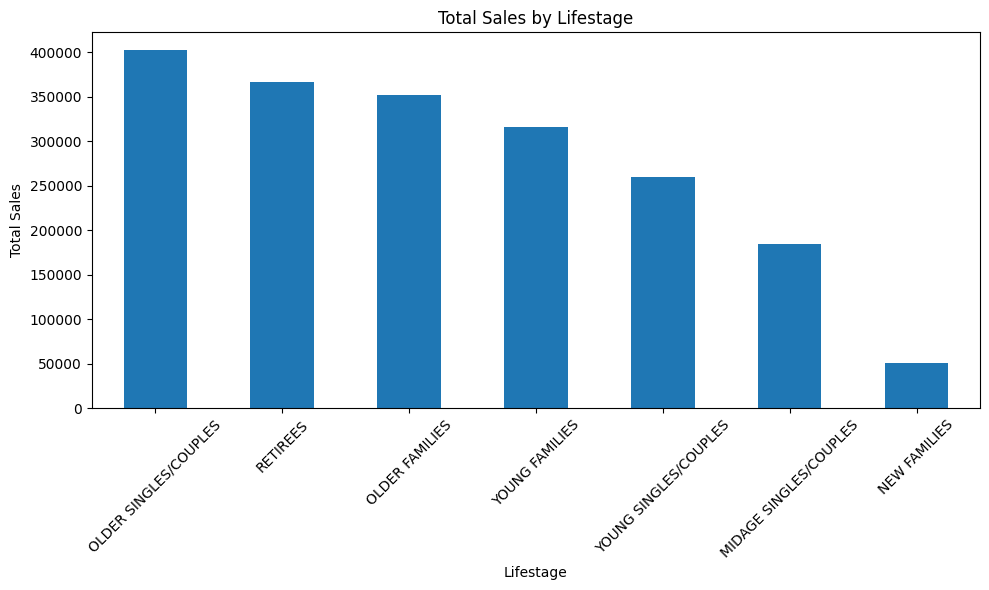

In [53]:
import matplotlib.pyplot as plt

sales_by_lifestage.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Total Sales by Lifestage")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

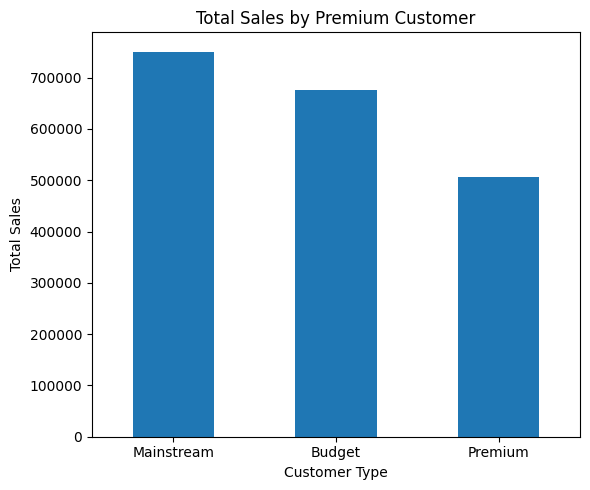

In [54]:
sales_by_premium.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Total Sales by Premium Customer")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

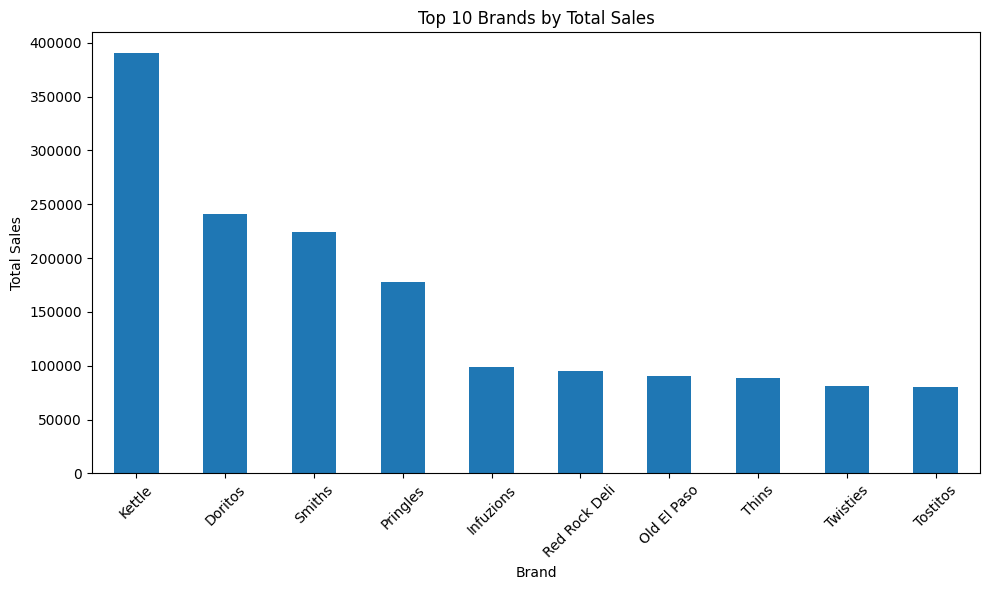

In [55]:
top10_brands = brand_sales.head(10)

top10_brands.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 10 Brands by Total Sales")
plt.xlabel("Brand")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

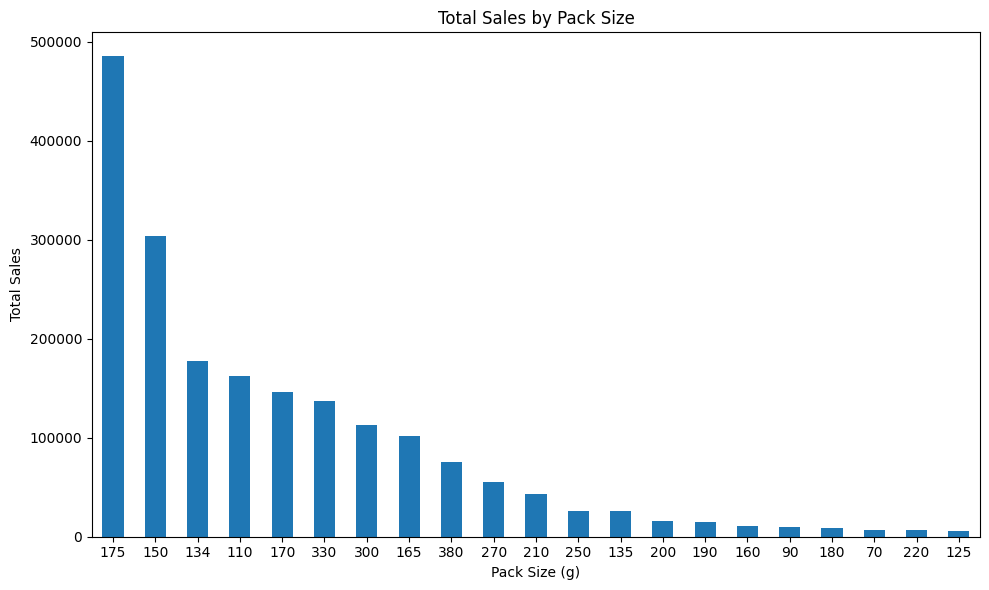

In [56]:
pack_size_sales.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Total Sales by Pack Size")
plt.xlabel("Pack Size (g)")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

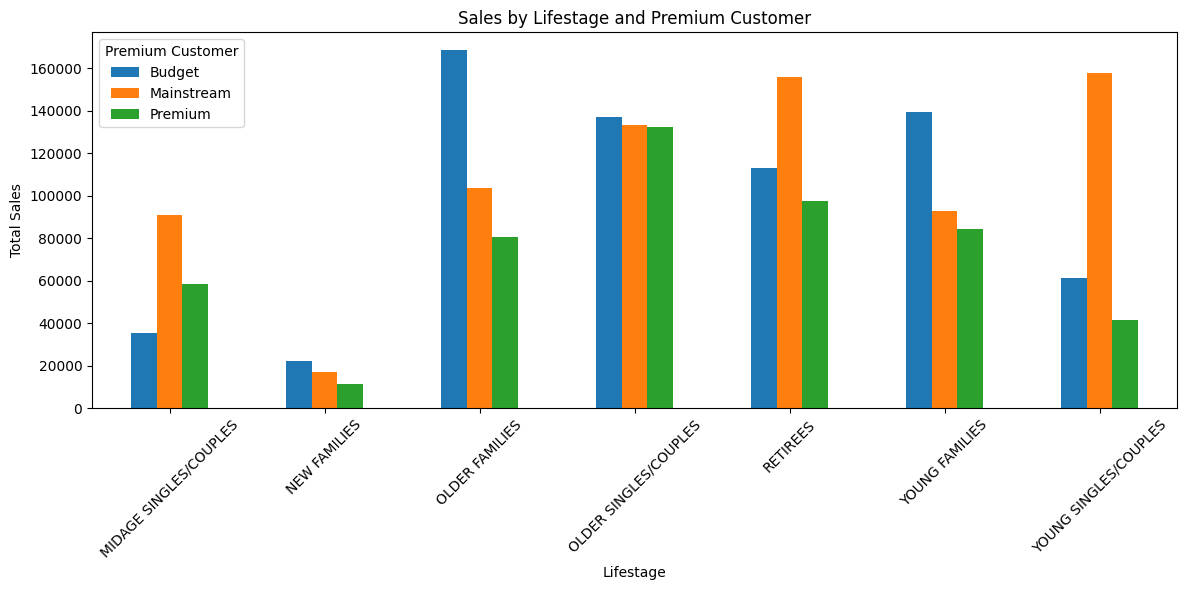

In [57]:
sales_segment_chart = merged_data.pivot_table(
    values="TOT_SALES",
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    aggfunc="sum"
)

sales_segment_chart.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Sales by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")
plt.tight_layout()
plt.show()

**KEY BUSINESS INSIGHTS**

**1. Older Families are the highest-value customer segment**

Although Older Singles/Couples generated the highest total sales overall by lifestage, Older Families recorded the highest average sales per customer (approximately 36.54) and purchased the highest average number of chip packets per customer (approximately 9.80). This indicates that Older Families are the most valuable customer segment in terms of individual spending and purchasing volume.

**2. Mainstream customers generated the highest overall sales**

Among the three customer categories, Mainstream customers contributed the highest total sales (750,744.50), followed by Budget and Premium customers. This suggests that Mainstream customers represent an important revenue-generating segment.

**3. Young Singles/Couples (Mainstream) pay the highest price per unit**

The Young Singles/Couples – Mainstream segment recorded the highest average price per unit (4.08), indicating a stronger preference for premium or higher-priced chip products compared to other customer groups.

**4. Kettle is the highest-selling chip brand**

Among all brands, Kettle generated the highest total sales, followed by Doritos, Smiths, and Pringles. These brands contribute significantly to overall category revenue.

**5. Medium-sized packs dominate sales**

The 175g pack size generated the highest total sales, followed by 150g and 134g packs. This suggests that medium-sized chip packs are the most popular among customers.

**6. Customer purchasing behaviour differs across segments**

Different customer segments contribute to sales in different ways. Older Families purchase more packets per customer, while Young Singles/Couples (Mainstream) spend more per unit. These differences indicate that purchasing behaviour varies significantly across customer segments.

**RECOMMENDATIONS FOR JULIA**

**Recommendation 1**

Focus marketing campaigns on Older Families, as they generate the highest average sales per customer and purchase the largest number of chip packets. Promotional offers such as multi-pack discounts and family bundle deals may encourage even higher sales.

**Recommendation 2**

Develop targeted promotions for Young Singles/Couples (Mainstream) by featuring premium brands and new product launches. Their willingness to pay the highest average price per unit suggests they are less price-sensitive and more likely to purchase premium products.

**Recommendation 3**

Maintain strong inventory levels for Kettle, Doritos, Smiths, and Pringles, as these brands contribute the largest share of chip sales and are important drivers of category revenue.

**Recommendation 4**

Prioritize 175g and 150g pack sizes in inventory planning and promotional activities, as these pack sizes generate the highest sales and are preferred by customers.

**Recommendation 5**

Continue monitoring purchasing behaviour across customer segments to identify changes in customer preferences and adjust marketing strategies accordingly.

# Task 3

In [3]:
import pandas as pd

In [3]:
presentation = pd.read_csv('QVI_Merged_Cleaned_Data.csv')

In [4]:
presentation.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,17-10-2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co.,YOUNG SINGLES/COUPLES,Premium
1,14-05-2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,20-05-2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,17-08-2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,18-08-2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [6]:
presentation.columns.tolist()

['DATE',
 'STORE_NBR',
 'LYLTY_CARD_NBR',
 'TXN_ID',
 'PROD_NBR',
 'PROD_NAME',
 'PROD_QTY',
 'TOT_SALES',
 'PACK_SIZE',
 'BRAND',
 'LIFESTAGE',
 'PREMIUM_CUSTOMER']

In [8]:
# ==========================================================
# Monthly Category Sales
# ==========================================================

presentation["DATE"] = pd.to_datetime(
    presentation["DATE"],
    dayfirst=True
)

monthly_sales = (
    presentation
    .groupby(
        presentation["DATE"].dt.to_period("M")
    )["TOT_SALES"]
    .sum()
    .reset_index()
)

monthly_sales["DATE"] = monthly_sales["DATE"].astype(str)

monthly_sales

,DATE,TOT_SALES
0,2018-07,165275.30
1,2018-08,158081.05
2,2018-09,160522.00
3,2018-10,164409.70
4,2018-11,160233.70
5,2018-12,167913.40
6,2019-01,162642.30
7,2019-02,150665.00
8,2019-03,166265.20
9,2019-04,159845.10


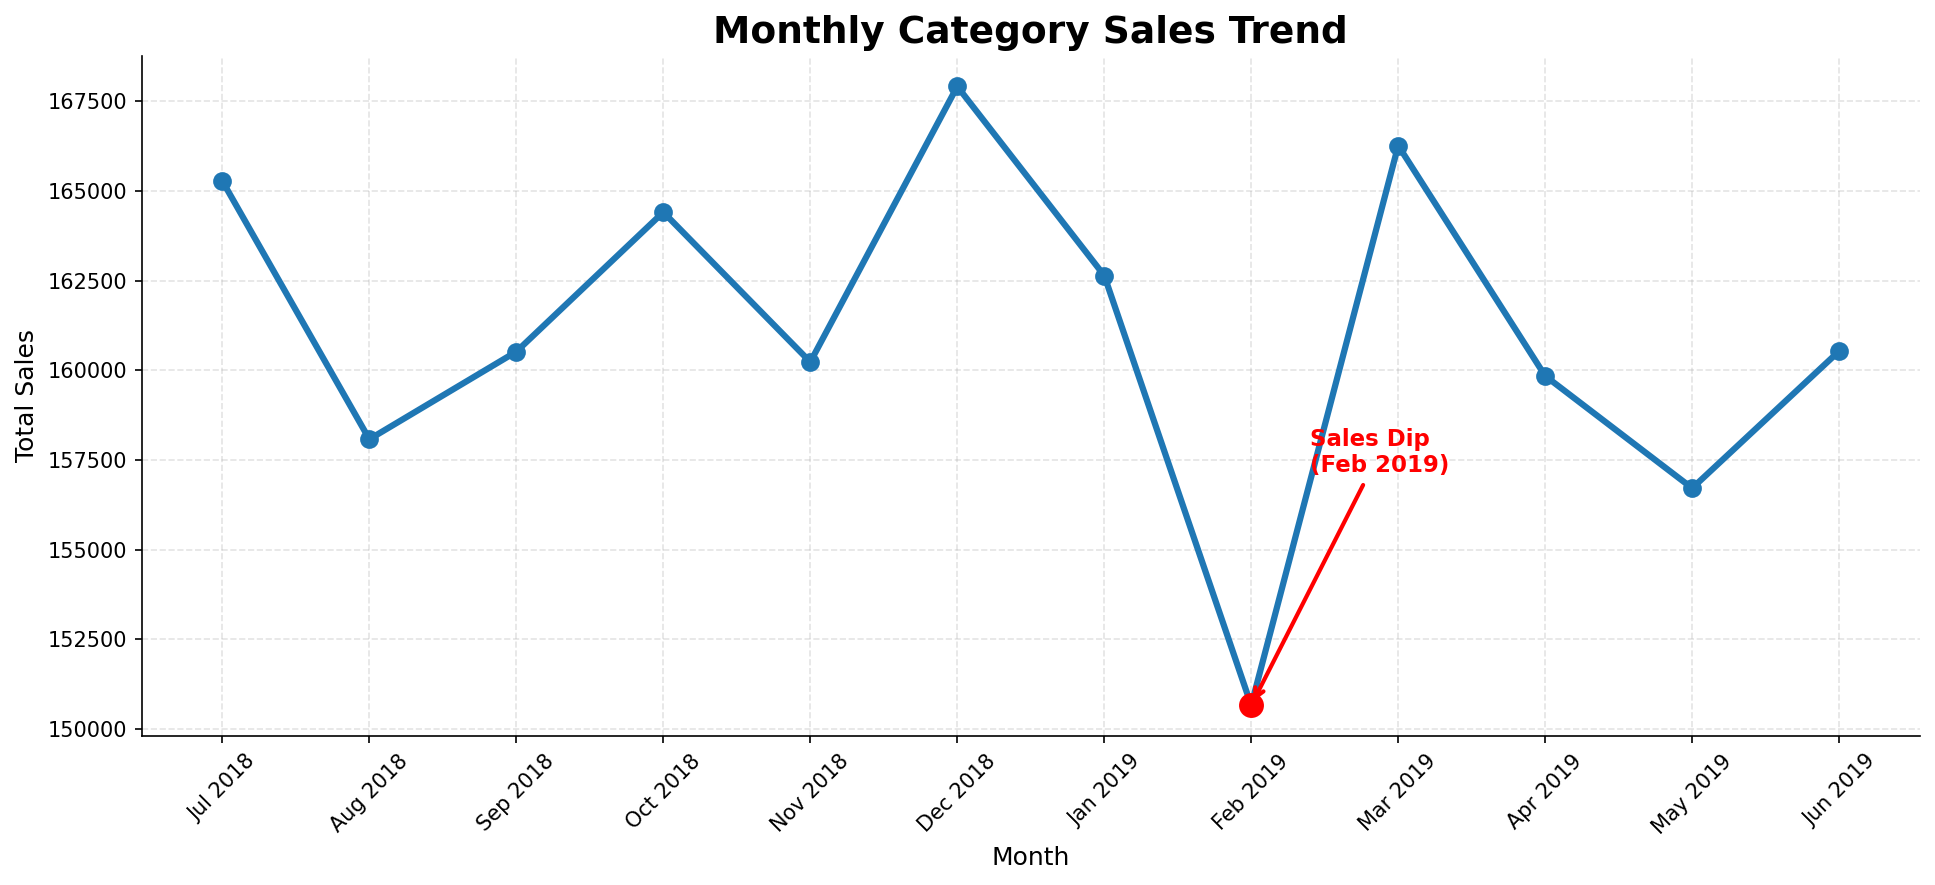

In [11]:
# ==========================================================
# Monthly Category Sales Trend
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------
# Create Month Labels
# ---------------------------------------

monthly_sales["Month"] = pd.to_datetime(
    monthly_sales["DATE"]
).dt.strftime("%b %Y")

# ---------------------------------------
# Find Lowest Sales Month
# ---------------------------------------

lowest_point = monthly_sales.loc[
    monthly_sales["TOT_SALES"].idxmin()
]

# ---------------------------------------
# Create Figure
# ---------------------------------------

plt.figure(figsize=(13, 6), dpi=150)

# ---------------------------------------
# Plot Monthly Sales
# ---------------------------------------

plt.plot(
    monthly_sales["Month"],
    monthly_sales["TOT_SALES"],
    color="#1f77b4",
    linewidth=3,
    marker="o",
    markersize=8
)

# ---------------------------------------
# Highlight Lowest Sales Point
# ---------------------------------------

plt.scatter(
    lowest_point["Month"],
    lowest_point["TOT_SALES"],
    color="red",
    s=120,
    zorder=5
)

# ---------------------------------------
# Callout for Sales Dip
# ---------------------------------------

plt.annotate(
    "Sales Dip\n(Feb 2019)",
    xy=(
        lowest_point["Month"],
        lowest_point["TOT_SALES"]
    ),
    xytext=(
        7.4,
        lowest_point["TOT_SALES"] + 6500
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    fontsize=11,
    fontweight="bold",
    color="red"
)

# ---------------------------------------
# Title
# ---------------------------------------

plt.title(
    "Monthly Category Sales Trend",
    fontsize=18,
    fontweight="bold"
)

# ---------------------------------------
# Axis Labels
# ---------------------------------------

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

# ---------------------------------------
# Rotate Month Labels
# ---------------------------------------

plt.xticks(rotation=45)

# ---------------------------------------
# Grid
# ---------------------------------------

plt.grid(
    linestyle="--",
    alpha=0.35
)

# ---------------------------------------
# Remove Extra Borders
# ---------------------------------------

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------
# Adjust Layout
# ---------------------------------------

plt.tight_layout()

plt.show()

In [12]:
# ==========================================================
# Customer Proportion by Lifestage and Premium Customer
# ==========================================================

customer_proportion = (
    presentation
    .groupby(
        ["LIFESTAGE", "PREMIUM_CUSTOMER"]
    )["LYLTY_CARD_NBR"]
    .nunique()
    .unstack()
)

# Convert counts to percentages
customer_proportion = (
    customer_proportion.div(
        customer_proportion.sum(axis=1),
        axis=0
    ) * 100
)

customer_proportion = customer_proportion.round(2)

customer_proportion

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,20.67,45.91,33.42
NEW FAMILIES,43.62,33.31,23.07
OLDER FAMILIES,47.81,28.95,23.24
OLDER SINGLES/COUPLES,33.74,33.75,32.51
RETIREES,30.08,43.76,26.15
YOUNG FAMILIES,43.77,29.72,26.51
YOUNG SINGLES/COUPLES,26.17,56.01,17.82


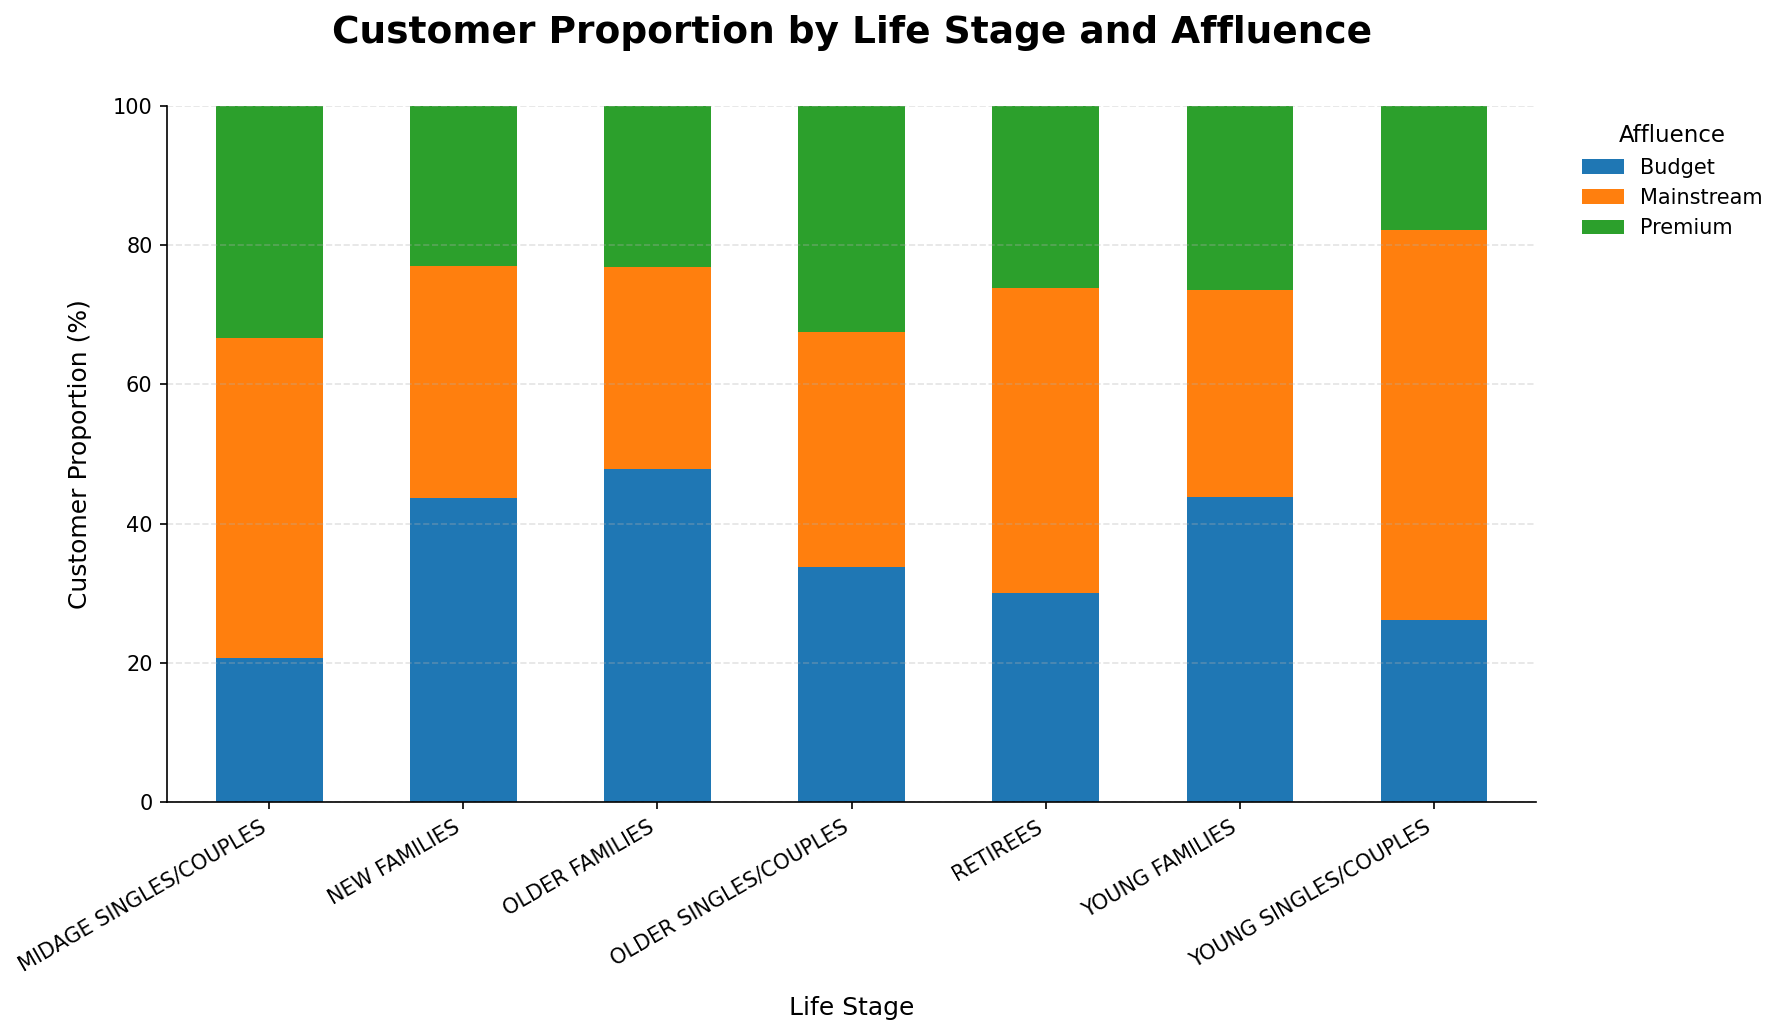

In [15]:
# ==========================================================
# Proportion of Customers by Life Stage and Affluence
# (100% Stacked Bar Chart)
# ==========================================================

import matplotlib.pyplot as plt

# ---------------------------------------
# Create Figure
# ---------------------------------------

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

# ---------------------------------------
# Plot Stacked Bar Chart
# ---------------------------------------

customer_proportion.plot(
    kind="bar",
    stacked=True,
    width=0.55,          # Slimmer bars
    ax=ax
)

# ---------------------------------------
# Chart Title
# ---------------------------------------

ax.set_title(
    "Customer Proportion by Life Stage and Affluence",
    fontsize=18,
    fontweight="bold",
    pad=30               # More space between title and chart
)

# ---------------------------------------
# Axis Labels
# ---------------------------------------

ax.set_xlabel(
    "Life Stage",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "Customer Proportion (%)",
    fontsize=12,
    labelpad=10
)

# ---------------------------------------
# Rotate X-axis Labels
# ---------------------------------------

plt.xticks(
    rotation=30,
    ha="right",
    fontsize=10
)

plt.yticks(
    fontsize=10
)

# ---------------------------------------
# Y-axis Limits
# ---------------------------------------

ax.set_ylim(0, 100)

# ---------------------------------------
# Horizontal Grid
# ---------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# ---------------------------------------
# Legend
# ---------------------------------------

ax.legend(
    title="Affluence",
    title_fontsize=11,
    fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# ---------------------------------------
# Remove Unnecessary Borders
# ---------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------
# Improve Layout
# ---------------------------------------

plt.tight_layout()

plt.show()